In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv', encoding='latin1')
df = df.dropna(subset=['Postal Code'])

Q1, Q3 = df['Sales'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['Sales_Outlier_Flag'] = ((df['Sales'] < lower) | (df['Sales'] > upper))

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df.shape

(9789, 19)

In [7]:
df.describe()
df['Category'].value_counts()
df['Sub-Category'].value_counts()
df['Region'].value_counts()
df['Segment'].value_counts()

Segment
Consumer       5096
Corporate      2948
Home Office    1745
Name: count, dtype: int64

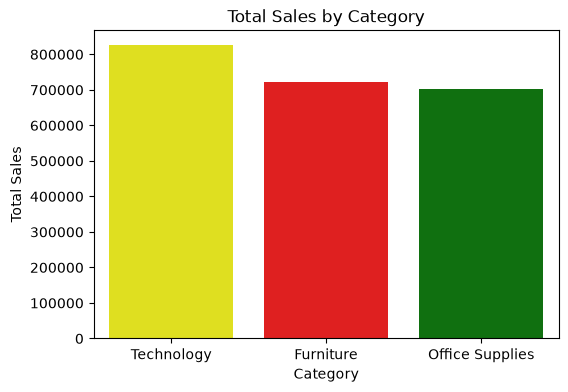

In [25]:
category_sales= df.groupby("Category")['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=category_sales.index, y=category_sales.values,hue=category_sales.index, palette=['yellow', 'red' , 'green'],legend=False)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()


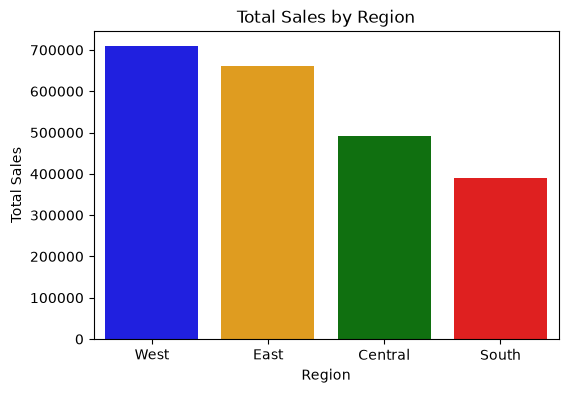

In [22]:
total_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=total_sales.index, y=total_sales.values, hue=total_sales.index, palette=['blue', 'orange', 'green', 'red'], legend=False)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

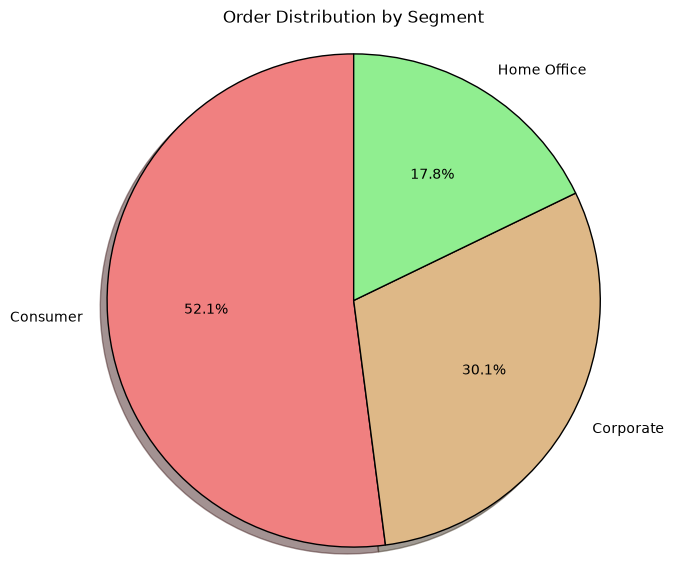

In [11]:
segment_counts = df['Segment'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=['lightcoral', 'burlywood', 'lightgreen'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.title('Order Distribution by Segment')
plt.axis('equal')  # keeps it a perfect circle
plt.show()

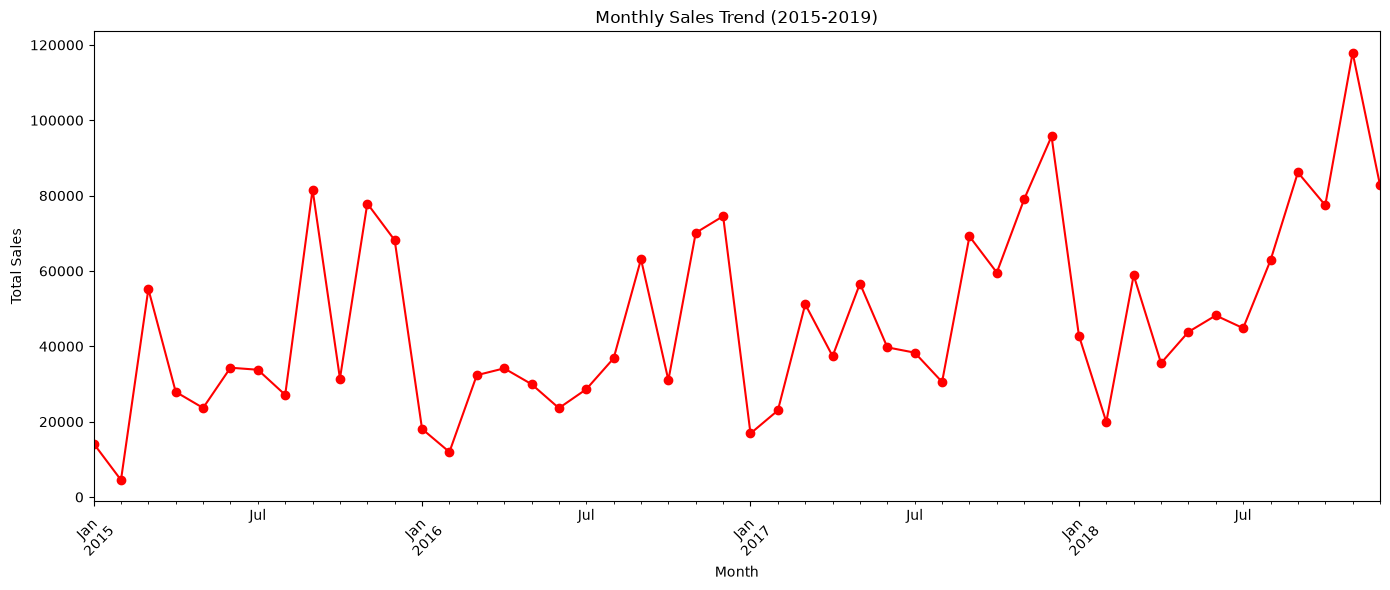

In [14]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o', color='red')
plt.title('Monthly Sales Trend (2015-2019)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

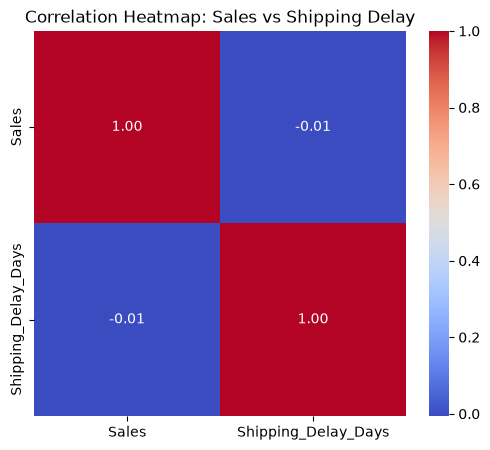

In [22]:

numeric_cols = df[['Sales', 'Shipping_Delay_Days']]
corr = numeric_cols.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Sales vs Shipping Delay')
plt.show()

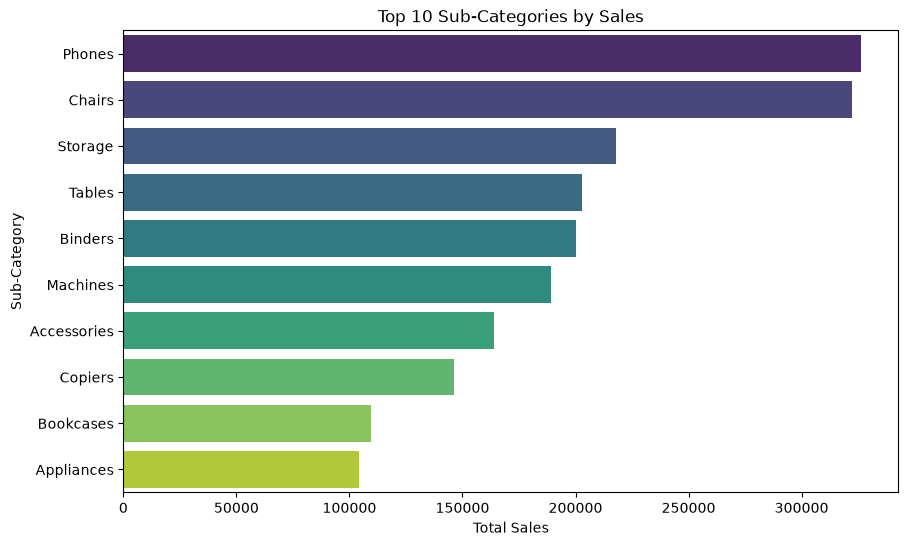

In [16]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, hue=subcat_sales.index, palette='viridis', legend=False)
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.show()

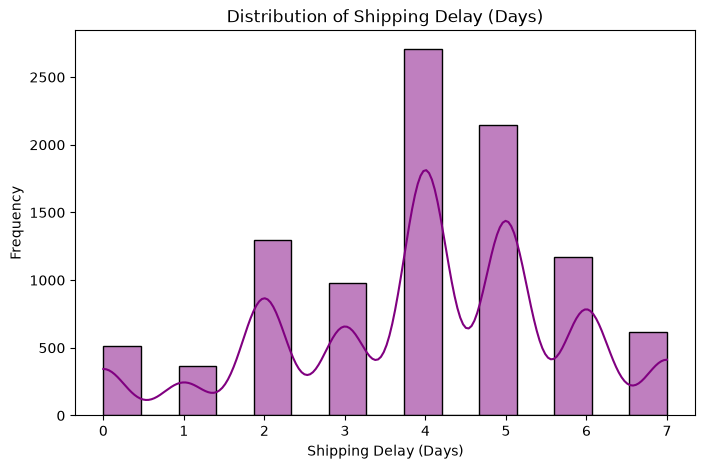

In [18]:
df['Shipping_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

plt.figure(figsize=(8,5))
sns.histplot(df['Shipping_Delay_Days'], bins=15, color='purple', kde=True)
plt.title('Distribution of Shipping Delay (Days)')
plt.xlabel('Shipping Delay (Days)')
plt.ylabel('Frequency')
plt.show()

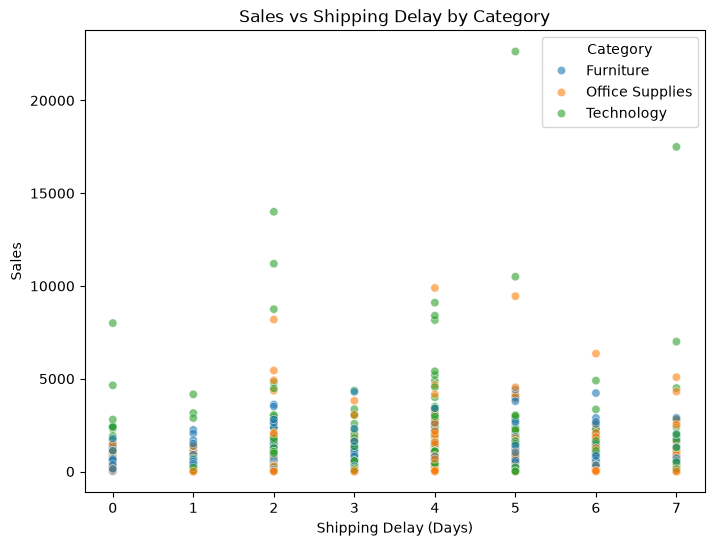

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Shipping_Delay_Days', y='Sales', data=df, hue='Category', alpha=0.6)
plt.title('Sales vs Shipping Delay by Category')
plt.xlabel('Shipping Delay (Days)')
plt.ylabel('Sales')
plt.show()

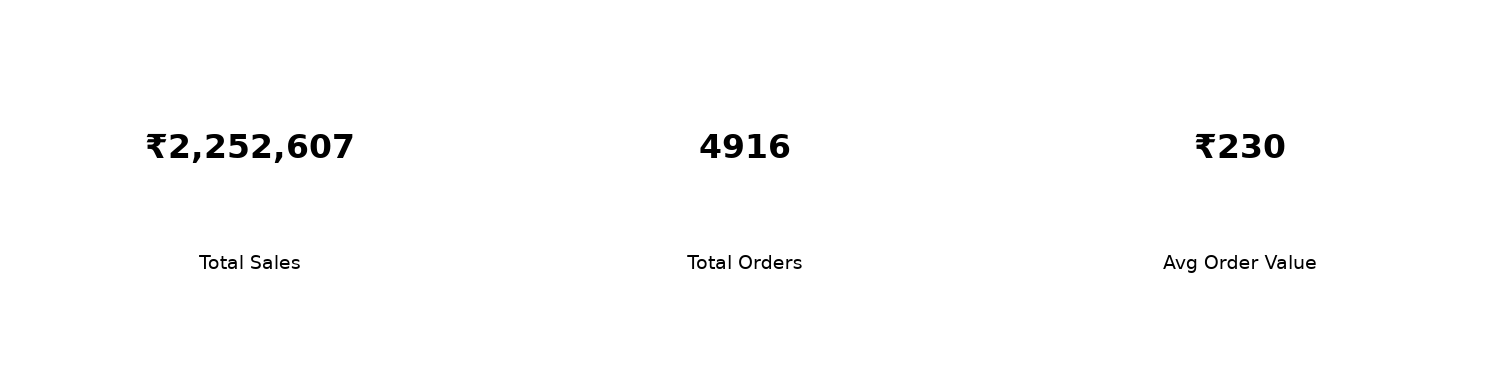

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
metrics = [('Total Sales', f'₹{total_sales:,.0f}'), 
           ('Total Orders', f'{total_orders}'), 
           ('Avg Order Value', f'₹{avg_order_value:,.0f}')]

for ax, (label, value) in zip(axes, metrics):
    ax.text(0.5, 0.6, value, fontsize=24, ha='center', fontweight='bold')
    ax.text(0.5, 0.3, label, fontsize=14, ha='center')
    ax.axis('off')

plt.tight_layout()
plt.show()